# 6. Ієрархічна кластеризація (Agglomerative)

Агломеративний підхід "знизу вгору": кожна точка — окремий кластер → об'єднуються найближчі → до досягнення k.

**Ward linkage** мінімізує внутрішньокластерну дисперсію.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data_processed.csv')
with open('top4_pairs.json') as f:
    pairs = json.load(f)

np.random.seed(42)
idx_s = np.random.choice(len(df), min(5000, len(df)), replace=False)
df_s = df.iloc[idx_s].reset_index(drop=True)
print(f"Вибірка: {df_s.shape}")
N = len(pairs)

Вибірка: (5000, 5)


## 6.1 Дендрограми

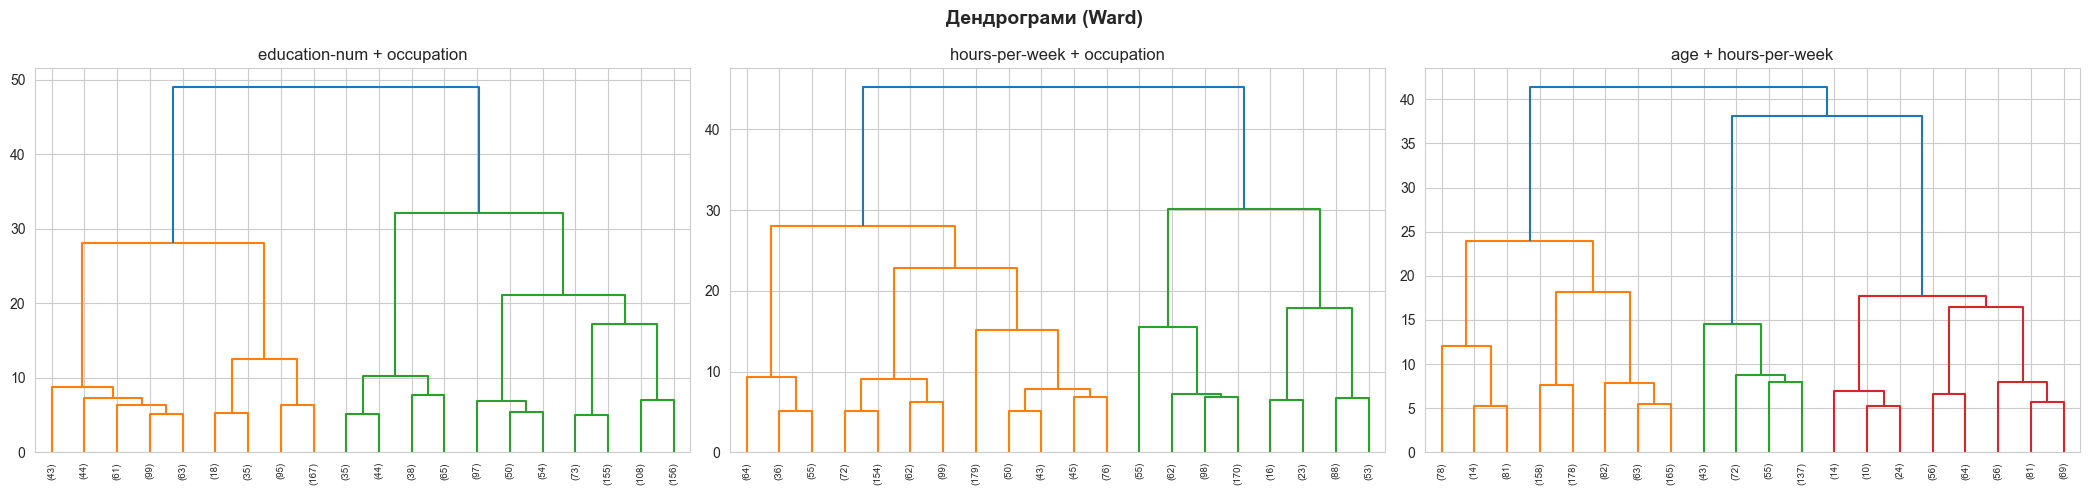

In [2]:
idx_d = np.random.choice(len(df_s), 1500, replace=False)
fig, axes = plt.subplots(1, N, figsize=(7*N, 5))
for j, pair in enumerate(pairs):
    X_d = StandardScaler().fit_transform(df_s[pair].values[idx_d])
    Z = linkage(X_d, method='ward')
    dendrogram(Z, truncate_mode='lastp', p=20, ax=axes[j], leaf_rotation=90, leaf_font_size=7)
    axes[j].set_title(f'{pair[0]} + {pair[1]}')
plt.suptitle('Дендрограми (Ward)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.2 Підбір k

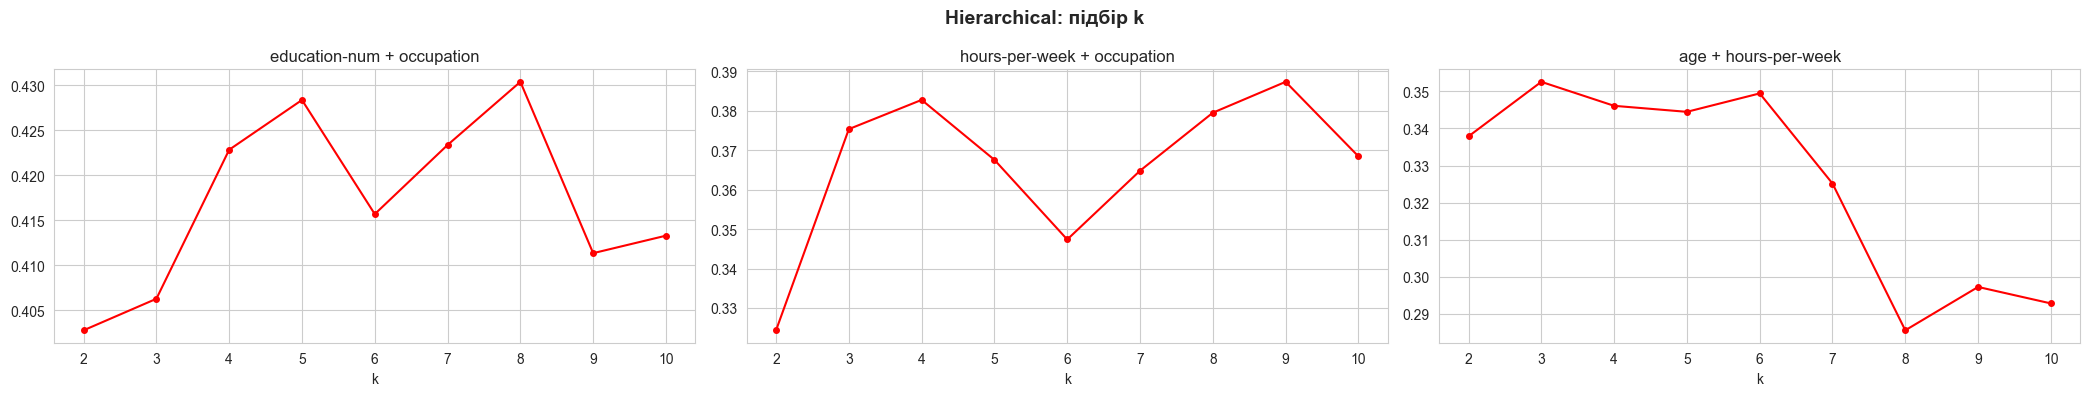

education-num + occupation: k = 8
hours-per-week + occupation: k = 9
age + hours-per-week: k = 3


In [3]:
K_range = range(2, 11)
best_k = {}
fig, axes = plt.subplots(1, N, figsize=(7*N, 4))
for j, pair in enumerate(pairs):
    X = StandardScaler().fit_transform(df_s[pair].values)
    sils = [silhouette_score(X, AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)) for k in K_range]
    axes[j].plot(list(K_range), sils, 'ro-', markersize=4)
    axes[j].set_title(f'{pair[0]} + {pair[1]}'); axes[j].set_xlabel('k')
    best_k[j] = list(K_range)[np.argmax(sils)]
plt.suptitle('Hierarchical: підбір k', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
for j, p in enumerate(pairs): print(f"{p[0]} + {p[1]}: k = {best_k[j]}")

## 6.3 Кластеризація та 2D-візуалізація

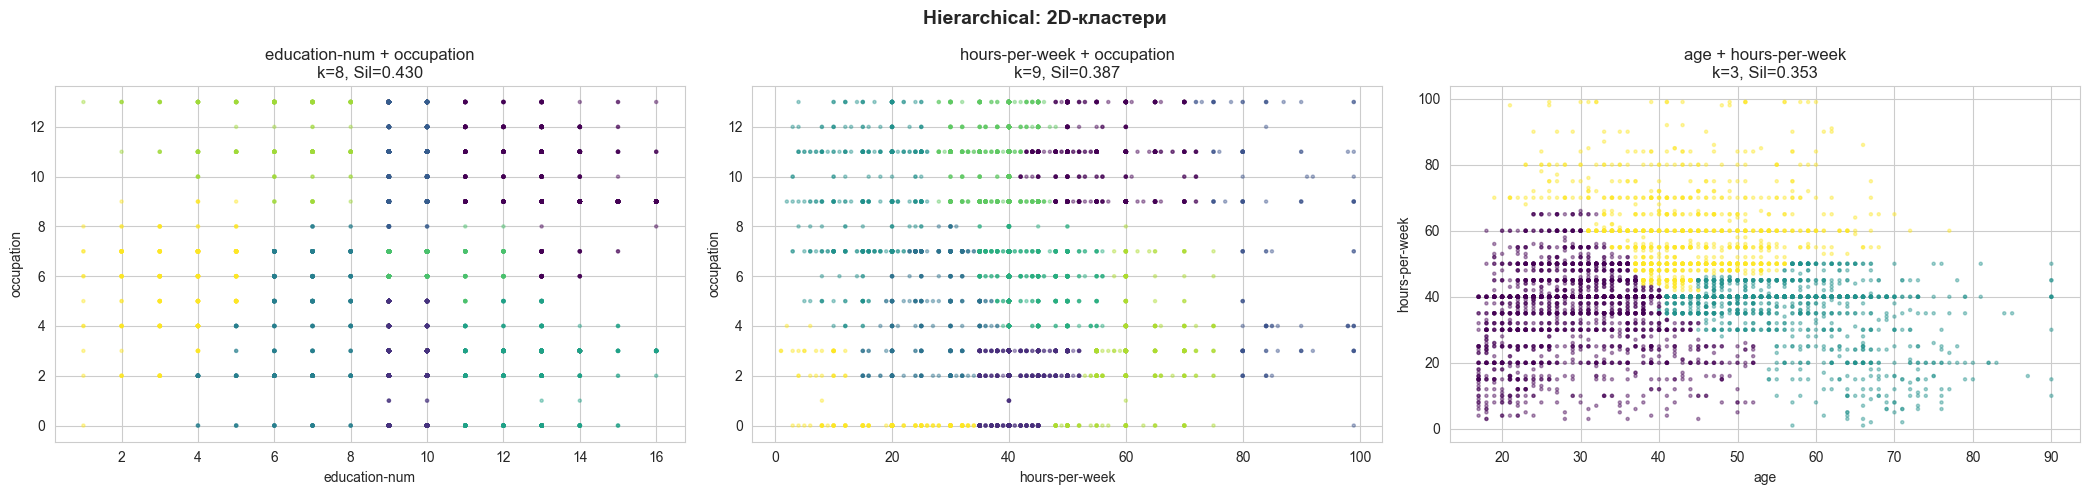

,algorithm,pair,k,silhouette,davies_bouldin,calinski_harabasz,time
0,Hierarchical,education-num + occupation,8,0.430398,0.823204,4674.890357,0.215426
1,Hierarchical,hours-per-week + occupation,9,0.387368,0.868813,3467.129088,0.262327
2,Hierarchical,age + hours-per-week,3,0.352566,0.941066,2801.710203,0.299471


In [4]:
all_results = []
fig, axes = plt.subplots(1, N, figsize=(7*N, 5))

for j, pair in enumerate(pairs):
    X_raw = df_s[pair].values
    X = StandardScaler().fit_transform(X_raw)
    k = best_k[j]
    
    start = time.time()
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)
    elapsed = time.time() - start
    
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    all_results.append({'algorithm': 'Hierarchical', 'pair': f'{pair[0]} + {pair[1]}',
                        'k': int(k), 'silhouette': sil, 'davies_bouldin': db,
                        'calinski_harabasz': ch, 'time': elapsed})
    
    idx = np.random.RandomState(42).choice(len(X_raw), min(5000, len(X_raw)), replace=False)
    axes[j].scatter(X_raw[idx, 0], X_raw[idx, 1], c=labels[idx], cmap='viridis', alpha=0.4, s=5)
    axes[j].set_xlabel(pair[0]); axes[j].set_ylabel(pair[1])
    axes[j].set_title(f'{pair[0]} + {pair[1]}\nk={k}, Sil={sil:.3f}')

plt.suptitle('Hierarchical: 2D-кластери', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(all_results)
results_df.to_csv('results_hierarchical.csv', index=False)
results_df